In [1]:
# 🫀 Heart Disease Early Detection
## Prediksi Dini Penyakit Jantung Berbasis Machine Learning



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier 
from sklearn.metrics import (accuracy_score,f1_score, roc_auc_score,confusion_matrix,roc_curve,classification_report)

from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

print("All Library Successfuly Added")

All Library Successfuly Added


In [3]:
df = pd.read_csv('../heart.csv')
print(f"Total data: {len(df)} baris, {len(df.columns)} kolom")
print()
print(df.head())
print()
print(df.info())

Total data: 918 baris, 12 kolom

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          -------------

In [4]:
stats = df[['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'HeartDisease', 'Oldpeak']].agg([
    'mean',
    'median',
    lambda x: x.mode()[0],  # mode
    'var',                   # variance
    'std',                   # standar deviasi
    'min',
    'max'
])

stats.index = ['Mean', 'Median', 'Mode', 'Variance', 'Standar Deviasi', 'Min', 'Max']
print(stats)

                       Age   RestingBP   Cholesterol  FastingBS       MaxHR  \
Mean             53.510893  132.396514    198.799564   0.233115  136.809368   
Median           54.000000  130.000000    223.000000   0.000000  138.000000   
Mode             54.000000  120.000000      0.000000   0.000000  150.000000   
Variance         88.974254  342.773903  11964.891079   0.178968  648.228614   
Standar Deviasi   9.432617   18.514154    109.384145   0.423046   25.460334   
Min              28.000000    0.000000      0.000000   0.000000   60.000000   
Max              77.000000  200.000000    603.000000   1.000000  202.000000   

                 HeartDisease   Oldpeak  
Mean                 0.553377  0.887364  
Median               1.000000  0.600000  
Mode                 1.000000  0.000000  
Variance             0.247420  1.137572  
Standar Deviasi      0.497414  1.066570  
Min                  0.000000 -2.600000  
Max                  1.000000  6.200000  


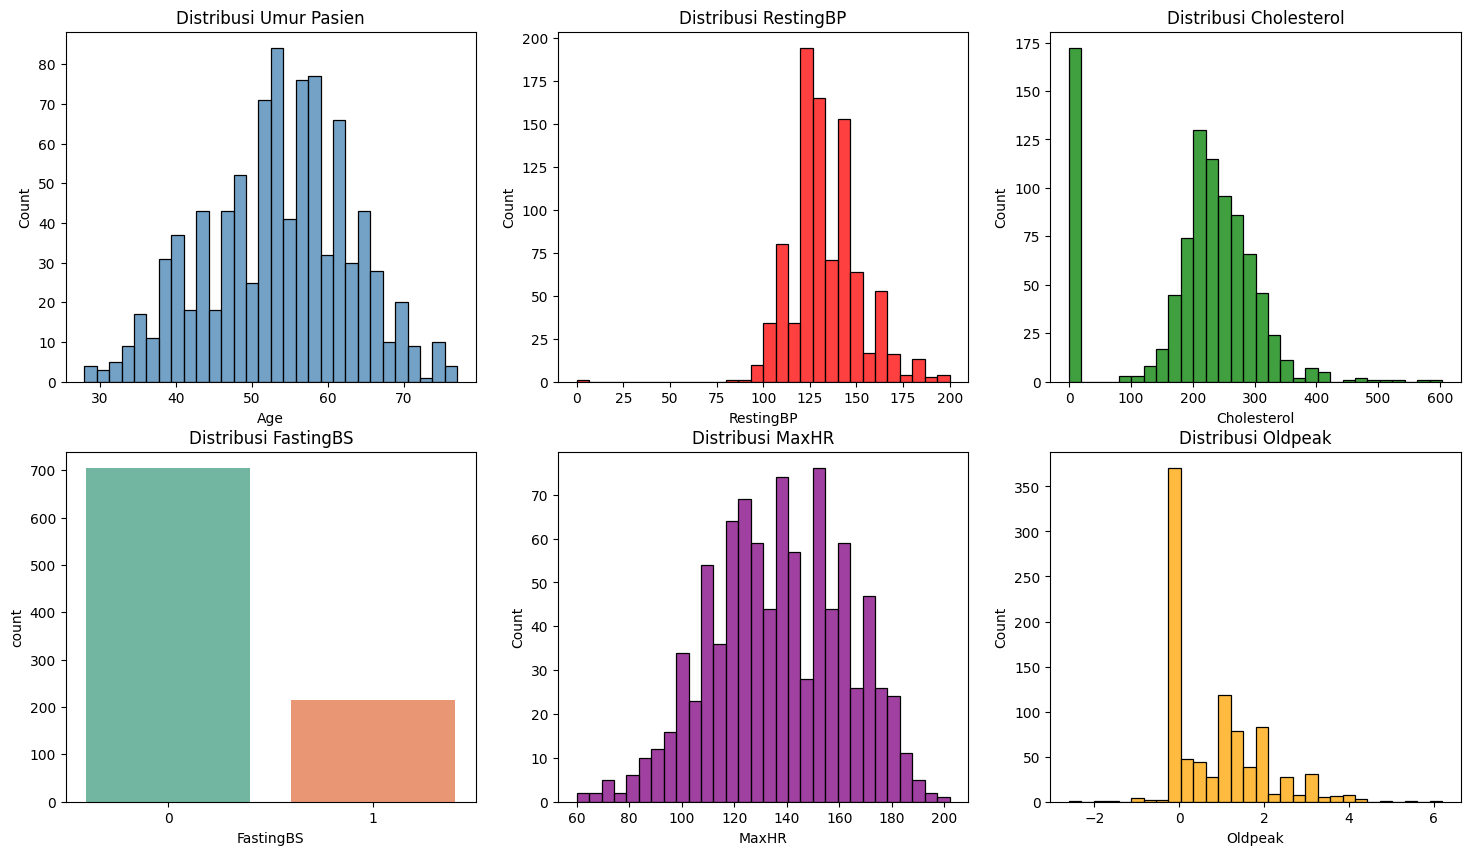

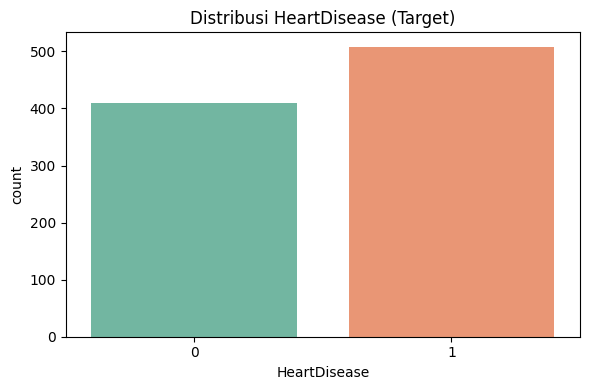

<Figure size 640x480 with 0 Axes>

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Age
sns.histplot(df['Age'], bins=30, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Distribusi Umur Pasien')
axes[0,0].set_xlabel('Age')

# 2. RestingBP
sns.histplot(df['RestingBP'], bins=30, ax=axes[0,1], color='red')
axes[0,1].set_title('Distribusi RestingBP')
axes[0,1].set_xlabel('RestingBP')

# 3. Cholesterol
sns.histplot(df['Cholesterol'], bins=30, ax=axes[0,2], color='green')
axes[0,2].set_title('Distribusi Cholesterol')
axes[0,2].set_xlabel('Cholesterol')

# 4. FastingBS
sns.countplot(x='FastingBS', data=df, ax=axes[1,0],
              hue='FastingBS', palette='Set2', legend=False)
axes[1,0].set_title('Distribusi FastingBS')

# 5. MaxHR
sns.histplot(df['MaxHR'], bins=30, ax=axes[1,1], color='purple')
axes[1,1].set_title('Distribusi MaxHR')
axes[1,1].set_xlabel('MaxHR')

# 6. Oldpeak
sns.histplot(df['Oldpeak'], bins=30, ax=axes[1,2], color='orange')
axes[1,2].set_title('Distribusi Oldpeak')
axes[1,2].set_xlabel('Oldpeak')

# 7. HeartDisease (target variable)
fig2, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='HeartDisease', data=df,
              hue='HeartDisease', palette='Set2', legend=False)
ax.set_title('Distribusi HeartDisease (Target)')
plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

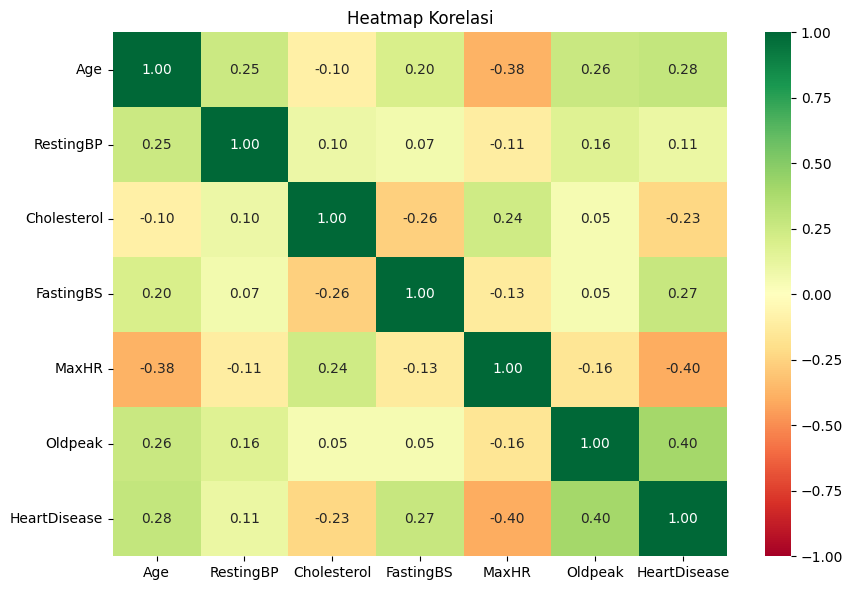

In [6]:
corr_cols = ['Age', 'RestingBP', 'Cholesterol', 
             'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']

plt.figure(figsize=(9, 6))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', 
            cmap='RdYlGn', vmin=-1, vmax=1)
plt.title('Heatmap Korelasi')
plt.tight_layout()
plt.show()

In [7]:
print(f"Cholesterol tidak normal (< 100): {(df['Cholesterol'] < 100).sum()} baris")
print(f"Cholesterol = 0: {(df['Cholesterol'] == 0).sum()} baris")
print()
print(f"RestingBP tidak normal (< 60): {(df['RestingBP'] < 60).sum()} baris")
print(f"RestingBP = 0: {(df['RestingBP'] == 0).sum()} baris")
print()
print(f"Total data: {len(df)} baris")

Cholesterol tidak normal (< 100): 173 baris
Cholesterol = 0: 172 baris

RestingBP tidak normal (< 60): 1 baris
RestingBP = 0: 1 baris

Total data: 918 baris


In [8]:
df = df[df['RestingBP'] !=0]
median_cholesterol = df[df['Cholesterol'] >= 100]['Cholesterol'].median()
df.loc[df['Cholesterol'] < 100, 'Cholesterol'] = median_cholesterol

print(f"Cholesterol tidak normal (< 100): {(df['Cholesterol'] < 100).sum()} baris")
print(f"RestingBP tidak normal (< 60): {(df['RestingBP'] < 60).sum()} baris")
print(f"Total data setelah cleaning: {len(df)} baris")

Cholesterol tidak normal (< 100): 0 baris
RestingBP tidak normal (< 60): 0 baris
Total data setelah cleaning: 917 baris


In [9]:
le = LabelEncoder()
df['Sex_Encoded'] = le.fit_transform(df['Sex'])
df['ChestPainType_Encoded'] = le.fit_transform(df['ChestPainType'])
df['RestingECG_Encoded'] = le.fit_transform(df['RestingECG'])
df['ST_Slope_Encoded'] =le.fit_transform(df['ST_Slope'])
df['ExerciseAngina_Encoded'] = le.fit_transform(df['ExerciseAngina'])

print(df[['Sex', 'Sex_Encoded',
          'ChestPainType', 'ChestPainType_Encoded',
          'RestingECG', 'RestingECG_Encoded',
          'ST_Slope', 'ST_Slope_Encoded',
          'ExerciseAngina', 'ExerciseAngina_Encoded']].head(3))


  Sex  Sex_Encoded ChestPainType  ChestPainType_Encoded RestingECG  \
0   M            1           ATA                      1     Normal   
1   F            0           NAP                      2     Normal   
2   M            1           ATA                      1         ST   

   RestingECG_Encoded ST_Slope  ST_Slope_Encoded ExerciseAngina  \
0                   1       Up                 2              N   
1                   1     Flat                 1              N   
2                   2       Up                 2              N   

   ExerciseAngina_Encoded  
0                       0  
1                       0  
2                       0  


In [10]:
scaler = MinMaxScaler()

scale_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak',
              'ChestPainType_Encoded', 'RestingECG_Encoded', 'ST_Slope_Encoded',
              'FastingBS', 'Sex_Encoded', 'ExerciseAngina_Encoded']

scaled_cols = ['Age_Scaled', 'RestingBP_Scaled', 'Cholesterol_Scaled', 
               'MaxHR_Scaled', 'Oldpeak_Scaled', 'ChestPainType_Encoded_Scaled',
               'RestingECG_Encoded_Scaled', 'ST_Slope_Encoded_Scaled',
               'FastingBS_Scaled', 'Sex_Encoded_Scaled', 'ExerciseAngina_Encoded_Scaled']

df[scaled_cols] = scaler.fit_transform(df[scale_cols])

print('Finish Scaling!')
print(df[scaled_cols].head(3))

Finish Scaling!
   Age_Scaled  RestingBP_Scaled  Cholesterol_Scaled  MaxHR_Scaled  \
0    0.244898          0.500000            0.375746      0.788732   
1    0.428571          0.666667            0.159046      0.676056   
2    0.183673          0.416667            0.363817      0.267606   

   Oldpeak_Scaled  ChestPainType_Encoded_Scaled  RestingECG_Encoded_Scaled  \
0        0.295455                      0.333333                        0.5   
1        0.409091                      0.666667                        0.5   
2        0.295455                      0.333333                        1.0   

   ST_Slope_Encoded_Scaled  FastingBS_Scaled  Sex_Encoded_Scaled  \
0                      1.0               0.0                 1.0   
1                      0.5               0.0                 0.0   
2                      1.0               0.0                 1.0   

   ExerciseAngina_Encoded_Scaled  
0                            0.0  
1                            0.0  
2               

In [11]:
# 1. Sex x ChestPainType
df['Sex_x_ChestPain'] = df['Sex_Encoded'] * df['ChestPainType_Encoded']

# 2. ExerciseAngina x Oldpeak
df['Exercise_x_Oldpeak'] = df['ExerciseAngina_Encoded'] * df['Oldpeak']

# 3. MaxHR x ST_Slope
df['MaxHR_x_STSlope'] = df['MaxHR'] * df['ST_Slope_Encoded']

# 4. Age x RestingBP
df['Age_x_RestingBP'] = df['Age'] * df['RestingBP']

# Verifikasi
print(df[['Sex_x_ChestPain', 'Exercise_x_Oldpeak', 
          'MaxHR_x_STSlope', 'Age_x_RestingBP']].head())

   Sex_x_ChestPain  Exercise_x_Oldpeak  MaxHR_x_STSlope  Age_x_RestingBP
0                1                 0.0              344             5600
1                0                 0.0              156             7840
2                1                 0.0              196             4810
3                0                 1.5              108             6624
4                2                 0.0              244             8100


In [12]:
scale_cols2 = ['MaxHR_x_STSlope', 'Age_x_RestingBP']
scaled_cols2 = ['MaxHR_x_STSlope_Scaled', 'Age_x_RestingBP_Scaled']

df[scaled_cols2] = scaler.fit_transform(df[scale_cols2])

print(df[scaled_cols2].head(3))

   MaxHR_x_STSlope_Scaled  Age_x_RestingBP_Scaled
0                0.851485                0.262295
1                0.386139                0.491803
2                0.485149                0.181352


In [13]:
print(df.columns.tolist())

['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease', 'Sex_Encoded', 'ChestPainType_Encoded', 'RestingECG_Encoded', 'ST_Slope_Encoded', 'ExerciseAngina_Encoded', 'Age_Scaled', 'RestingBP_Scaled', 'Cholesterol_Scaled', 'MaxHR_Scaled', 'Oldpeak_Scaled', 'ChestPainType_Encoded_Scaled', 'RestingECG_Encoded_Scaled', 'ST_Slope_Encoded_Scaled', 'FastingBS_Scaled', 'Sex_Encoded_Scaled', 'ExerciseAngina_Encoded_Scaled', 'Sex_x_ChestPain', 'Exercise_x_Oldpeak', 'MaxHR_x_STSlope', 'Age_x_RestingBP', 'MaxHR_x_STSlope_Scaled', 'Age_x_RestingBP_Scaled']


In [14]:
X = df[['Age_Scaled', 'RestingBP_Scaled', 'Cholesterol_Scaled', 
        'MaxHR_Scaled', 'Oldpeak_Scaled', 'ChestPainType_Encoded_Scaled', 
        'RestingECG_Encoded_Scaled', 'ST_Slope_Encoded_Scaled', 
        'FastingBS_Scaled', 'Sex_Encoded_Scaled', 'ExerciseAngina_Encoded_Scaled', 
        'Sex_x_ChestPain', 'Exercise_x_Oldpeak', 
        'MaxHR_x_STSlope_Scaled', 'Age_x_RestingBP_Scaled']]

y = df['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Data train: {len(X_train)} baris')
print(f'Data test: {len(X_test)} baris')

Data train: 733 baris
Data test: 184 baris


In [15]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import pandas as pd

models = { 
    'RandomForest': RandomForestClassifier(random_state=42), 
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

hasil = []

for nama, model in models.items():
    print(f'Training {nama}...')

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    hasil.append({'Model': nama, 'Accuracy': round(acc, 4),
    'F1_Score': round(f1, 4), 'ROC-AUC': round(roc, 4)})
    print(f'Accuracy: {acc:.4f} | F1: {f1:4f} | ROC-AUC: {roc:.4f}\n')
    hasil_df = pd.DataFrame(hasil)
    print('=== BASELINE (SEBELUM TUNING) ===')

    print(hasil_df.to_string(index=False))

Training RandomForest...
Accuracy: 0.8641 | F1: 0.886878 | ROC-AUC: 0.9323

=== BASELINE (SEBELUM TUNING) ===
       Model  Accuracy  F1_Score  ROC-AUC
RandomForest    0.8641    0.8869   0.9323
Training Gradient Boosting...
Accuracy: 0.8641 | F1: 0.886878 | ROC-AUC: 0.9283

=== BASELINE (SEBELUM TUNING) ===
            Model  Accuracy  F1_Score  ROC-AUC
     RandomForest    0.8641    0.8869   0.9323
Gradient Boosting    0.8641    0.8869   0.9283
Training XGBoost...
Accuracy: 0.8804 | F1: 0.900000 | ROC-AUC: 0.9307

=== BASELINE (SEBELUM TUNING) ===
            Model  Accuracy  F1_Score  ROC-AUC
     RandomForest    0.8641    0.8869   0.9323
Gradient Boosting    0.8641    0.8869   0.9283
          XGBoost    0.8804    0.9000   0.9307


In [16]:
print('=== CEK OVERFIT/UNDERFIT ===\n')

for nama, model in models.items():
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    gap = train_acc - test_acc
    
    print(f'{nama}:')
    print(f'  Train Accuracy : {train_acc:.4f}')
    print(f'  Test Accuracy  : {test_acc:.4f}')
    print(f'  Gap            : {gap:.4f}', end=' ')
    
    if gap > 0.1:
        print('over')
    elif train_acc < 0.75:
        print('under')
    else:
        print('ok')
    print()

=== CEK OVERFIT/UNDERFIT ===

RandomForest:
  Train Accuracy : 1.0000
  Test Accuracy  : 0.8641
  Gap            : 0.1359 over

Gradient Boosting:
  Train Accuracy : 0.9563
  Test Accuracy  : 0.8641
  Gap            : 0.0922 ok

XGBoost:
  Train Accuracy : 1.0000
  Test Accuracy  : 0.8804
  Gap            : 0.1196 over



In [17]:
from sklearn.model_selection import GridSearchCV

# ===== 1. Random Forest =====
rf_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,           # K-Fold 5
    scoring='roc_auc',
    n_jobs=-1,      # pakai semua core CPU
    verbose=1       # tampilkan progress
)
rf_grid.fit(X_train, y_train)
print(f'RF Best Params: {rf_grid.best_params_}')
print(f'RF Best Score: {rf_grid.best_score_:.4f}\n')

# ===== 2. Gradient Boosting =====
gb_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

gb_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
gb_grid.fit(X_train, y_train)
print(f'GB Best Params: {gb_grid.best_params_}')
print(f'GB Best Score: {gb_grid.best_score_:.4f}\n')

# ===== 3. XGBoost =====
xgb_params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    xgb_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(X_train, y_train)
print(f'XGB Best Params: {xgb_grid.best_params_}')
print(f'XGB Best Score: {xgb_grid.best_score_:.4f}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits
RF Best Params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
RF Best Score: 0.9205

Fitting 5 folds for each of 27 candidates, totalling 135 fits
GB Best Params: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 50}
GB Best Score: 0.9229

Fitting 5 folds for each of 27 candidates, totalling 135 fits
XGB Best Params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
XGB Best Score: 0.9235


In [18]:
# Evaluasi semua model setelah tuning
best_models = {
    'Random Forest': rf_grid.best_estimator_,
    'Gradient Boosting': gb_grid.best_estimator_,
    'XGBoost': xgb_grid.best_estimator_
}

print('=== HASIL SETELAH TUNING ===\n')
for nama, model in best_models.items():
    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))
    f1 = f1_score(y_test, model.predict(X_test))
    roc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    gap = train_acc - test_acc
    
    print(f'{nama}:')
    print(f'  Train Accuracy : {train_acc:.4f}')
    print(f'  Test Accuracy  : {test_acc:.4f}')
    print(f'  F1-Score       : {f1:.4f}')
    print(f'  ROC-AUC        : {roc:.4f}')
    print(f'  Gap            : {gap:.4f}', end=' ')
    
    if gap > 0.1:
        print('over')
    elif train_acc < 0.75:
        print('under')
    else:
        print('ok')
    print()

=== HASIL SETELAH TUNING ===

Random Forest:
  Train Accuracy : 0.8909
  Test Accuracy  : 0.8370
  F1-Score       : 0.8624
  ROC-AUC        : 0.9283
  Gap            : 0.0539 ok

Gradient Boosting:
  Train Accuracy : 0.9591
  Test Accuracy  : 0.8533
  F1-Score       : 0.8778
  ROC-AUC        : 0.9247
  Gap            : 0.1058 over

XGBoost:
  Train Accuracy : 0.9482
  Test Accuracy  : 0.8750
  F1-Score       : 0.8969
  ROC-AUC        : 0.9319
  Gap            : 0.0732 ok



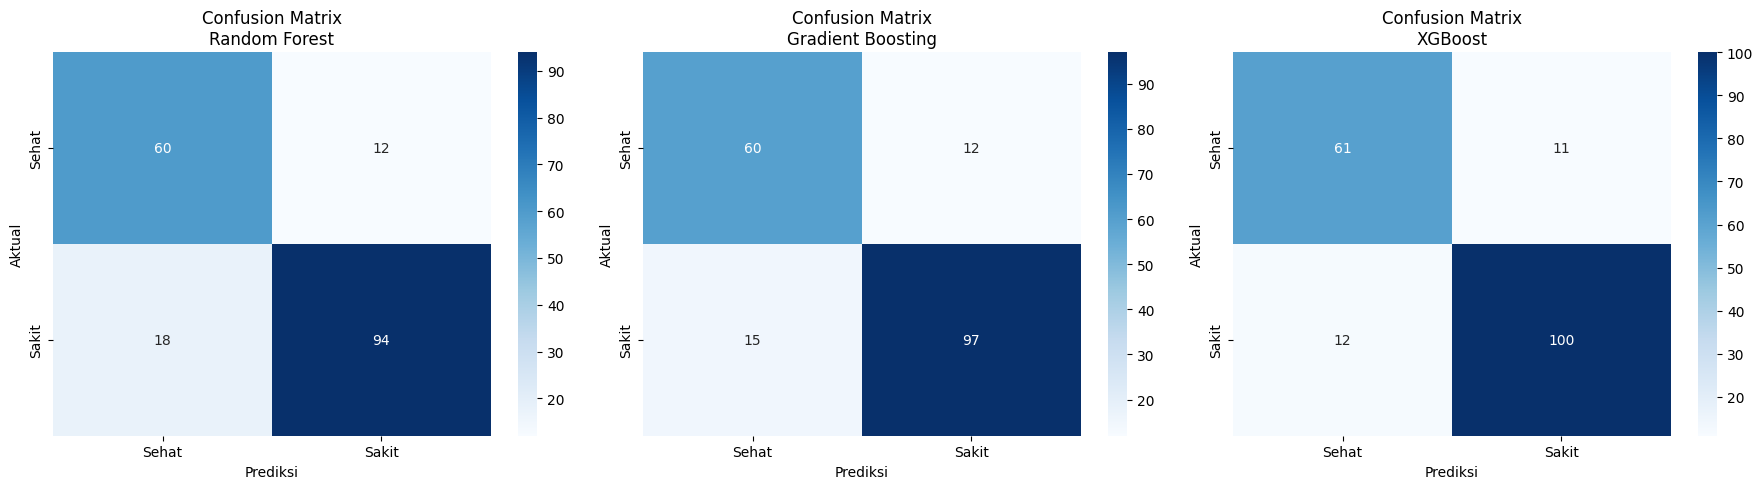

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (nama, model) in enumerate(best_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Sehat', 'Sakit'],
                yticklabels=['Sehat', 'Sakit'],
                ax=axes[idx])
    
    axes[idx].set_title(f'Confusion Matrix\n{nama}')
    axes[idx].set_xlabel('Prediksi')
    axes[idx].set_ylabel('Aktual')

plt.tight_layout()
plt.show()

In [20]:
from sklearn.metrics import classification_report

for nama, model in best_models.items():
    print(f"=== {nama} Classification Report ===")
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred, 
                                target_names=['Sehat', 'Sakit']))
    print()

=== Random Forest Classification Report ===
              precision    recall  f1-score   support

       Sehat       0.77      0.83      0.80        72
       Sakit       0.89      0.84      0.86       112

    accuracy                           0.84       184
   macro avg       0.83      0.84      0.83       184
weighted avg       0.84      0.84      0.84       184


=== Gradient Boosting Classification Report ===
              precision    recall  f1-score   support

       Sehat       0.80      0.83      0.82        72
       Sakit       0.89      0.87      0.88       112

    accuracy                           0.85       184
   macro avg       0.84      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184


=== XGBoost Classification Report ===
              precision    recall  f1-score   support

       Sehat       0.84      0.85      0.84        72
       Sakit       0.90      0.89      0.90       112

    accuracy                           0.88       

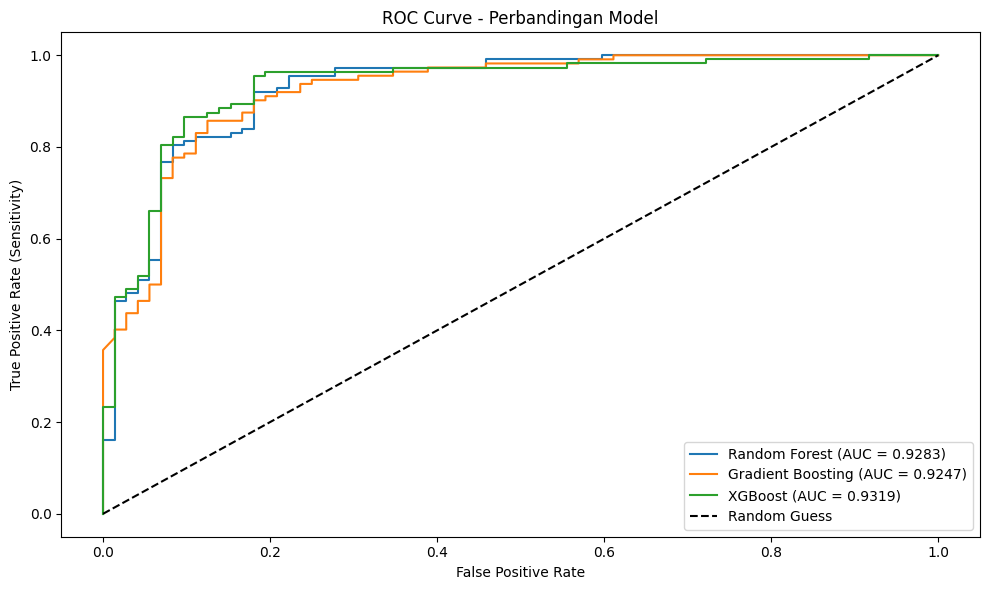

In [21]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for nama, model in best_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{nama} (AUC = {auc:.4f})')

# Garis diagonal = model acak (baseline)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve - Perbandingan Model')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
import pandas as pd
import numpy as np

def prediksi_pasien(age, sex, chest_pain, resting_bp, cholesterol,
                    fasting_bs, resting_ecg, max_hr, exercise_angina,
                    oldpeak, st_slope):
    
    # Encoding manual
    sex_enc = 1 if sex == 'M' else 0
    chest_pain_enc = {'ATA': 1, 'NAP': 2, 'ASY': 0, 'TA': 3}[chest_pain]
    resting_ecg_enc = {'Normal': 1, 'ST': 2, 'LVH': 0}[resting_ecg]
    st_slope_enc = {'Up': 2, 'Flat': 1, 'Down': 0}[st_slope]
    exercise_angina_enc = 1 if exercise_angina == 'Y' else 0
    
    # Normalisasi manual pakai min-max dari dataset
    age_scaled = (age - 28) / (77 - 28)
    resting_bp_scaled = (resting_bp - 60) / (200 - 60)
    cholesterol_scaled = (cholesterol - 100) / (603 - 100)
    max_hr_scaled = (max_hr - 60) / (202 - 60)
    oldpeak_scaled = (oldpeak - (-2.6)) / (6.2 - (-2.6))
    chest_pain_scaled = chest_pain_enc / 3
    resting_ecg_scaled = resting_ecg_enc / 2
    st_slope_scaled = st_slope_enc / 2
    fasting_bs_scaled = fasting_bs / 1
    sex_scaled = sex_enc / 1
    exercise_angina_scaled = exercise_angina_enc / 1
    
    # Feature engineering
    sex_x_chest = sex_enc * chest_pain_enc
    exercise_x_oldpeak = exercise_angina_enc * oldpeak
    maxhr_x_stslope = max_hr * st_slope_enc
    age_x_restingbp = age * resting_bp
    
    # Normalisasi fitur baru
    maxhr_x_stslope_scaled = (maxhr_x_stslope - 0) / (202 * 2 - 0)
    age_x_restingbp_scaled = (age_x_restingbp - 0) / (77 * 200 - 0)
    
    # Input final
    input_data = pd.DataFrame([{
        'Age_Scaled': age_scaled,
        'RestingBP_Scaled': resting_bp_scaled,
        'Cholesterol_Scaled': cholesterol_scaled,
        'MaxHR_Scaled': max_hr_scaled,
        'Oldpeak_Scaled': oldpeak_scaled,
        'ChestPainType_Encoded_Scaled': chest_pain_scaled,
        'RestingECG_Encoded_Scaled': resting_ecg_scaled,
        'ST_Slope_Encoded_Scaled': st_slope_scaled,
        'FastingBS_Scaled': fasting_bs_scaled,
        'Sex_Encoded_Scaled': sex_scaled,
        'ExerciseAngina_Encoded_Scaled': exercise_angina_scaled,
        'Sex_x_ChestPain': sex_x_chest,
        'Exercise_x_Oldpeak': exercise_x_oldpeak,
        'MaxHR_x_STSlope_Scaled': maxhr_x_stslope_scaled,
        'Age_x_RestingBP_Scaled': age_x_restingbp_scaled
    }])
    
    # Prediksi
    model = best_models['XGBoost']
    prediksi = model.predict(input_data)[0]
    probabilitas = model.predict_proba(input_data)[0]
    
    print("="*50)
    print("🏥 HASIL PREDIKSI PENYAKIT JANTUNG")
    print("="*50)
    print(f"Pasien: {age} tahun, {'Pria' if sex == 'M' else 'Wanita'}")
    print(f"Kolesterol: {cholesterol} | Tekanan Darah: {resting_bp}")
    print(f"Detak Jantung Max: {max_hr} | Oldpeak: {oldpeak}")
    print("-"*50)
    
    if prediksi == 1:
        print(f"⚠️  BERISIKO SAKIT JANTUNG")
        print(f"Probabilitas Sakit  : {probabilitas[1]:.2%}")
        print(f"Probabilitas Sehat  : {probabilitas[0]:.2%}")
    else:
        print(f"✅  TIDAK BERISIKO SAKIT JANTUNG")
        print(f"Probabilitas Sehat  : {probabilitas[0]:.2%}")
        print(f"Probabilitas Sakit  : {probabilitas[1]:.2%}")
    print("="*50)

# Pasien 1 - Berisiko tinggi
print("PASIEN 1:")
prediksi_pasien(
    age=30, sex='F', chest_pain='ASY', resting_bp=160,
    cholesterol=300, fasting_bs=1, resting_ecg='ST',
    max_hr=90, exercise_angina='Y', oldpeak=3.0, st_slope='Flat'
)

print()


print("PASIEN 2:")
prediksi_pasien(
    age=70, sex='F', chest_pain='ASY', resting_bp=120,
    cholesterol=200, fasting_bs=0, resting_ecg='Normal',
    max_hr=170, exercise_angina='N', oldpeak=0.0, st_slope='Up'
)

print("PASIEN AMBIGU:")
prediksi_pasien(
    age=45, sex='F', chest_pain='NAP', resting_bp=140,
    cholesterol=250, fasting_bs=0, resting_ecg='Normal',
    max_hr=120, exercise_angina='Y', oldpeak=1.5, st_slope='Flat'
)

PASIEN 1:
🏥 HASIL PREDIKSI PENYAKIT JANTUNG
Pasien: 30 tahun, Wanita
Kolesterol: 300 | Tekanan Darah: 160
Detak Jantung Max: 90 | Oldpeak: 3.0
--------------------------------------------------
⚠️  BERISIKO SAKIT JANTUNG
Probabilitas Sakit  : 95.38%
Probabilitas Sehat  : 4.62%

PASIEN 2:
🏥 HASIL PREDIKSI PENYAKIT JANTUNG
Pasien: 70 tahun, Wanita
Kolesterol: 200 | Tekanan Darah: 120
Detak Jantung Max: 170 | Oldpeak: 0.0
--------------------------------------------------
✅  TIDAK BERISIKO SAKIT JANTUNG
Probabilitas Sehat  : 93.10%
Probabilitas Sakit  : 6.90%
PASIEN AMBIGU:
🏥 HASIL PREDIKSI PENYAKIT JANTUNG
Pasien: 45 tahun, Wanita
Kolesterol: 250 | Tekanan Darah: 140
Detak Jantung Max: 120 | Oldpeak: 1.5
--------------------------------------------------
⚠️  BERISIKO SAKIT JANTUNG
Probabilitas Sakit  : 62.46%
Probabilitas Sehat  : 37.54%


In [25]:
import pickle

with open('xgboost_model.pkl', 'wb') as f:
    pickle.dump(best_models['XGBoost'], f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print('Model dan scaler berhasil disave')

Model dan scaler berhasil disave


In [27]:
import os 
print(os.getcwd())
print([f for f in os.listdir() if f.endswith('.pkl')])

/Users/mac/Documents/Dataset/ipynb
['scaler.pkl', 'xgboost_model.pkl']


In [28]:
import shutil
shutil.copy('xgboost_model.pkl', '../HeartDisease_WebApp/xgboost_model.pkl')
shutil.copy('scaler.pkl', '../HeartDisease_WebApp/scaler.pkl')

print('Succes')

Succes


In [32]:
print(scale_cols)

['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'ChestPainType_Encoded', 'RestingECG_Encoded', 'ST_Slope_Encoded', 'FastingBS', 'Sex_Encoded', 'ExerciseAngina_Encoded']


In [33]:
print(scale_cols)
print(scale_cols2)


['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'ChestPainType_Encoded', 'RestingECG_Encoded', 'ST_Slope_Encoded', 'FastingBS', 'Sex_Encoded', 'ExerciseAngina_Encoded']
['MaxHR_x_STSlope', 'Age_x_RestingBP']


In [36]:
from sklearn.preprocessing import MinMaxScaler
import pickle

# Scaler 1 - untuk 11 kolom utama
scaler1 = MinMaxScaler()
scale_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak',
              'ChestPainType_Encoded', 'RestingECG_Encoded', 'ST_Slope_Encoded',
              'FastingBS', 'Sex_Encoded', 'ExerciseAngina_Encoded']
df[['Age_Scaled', 'RestingBP_Scaled', 'Cholesterol_Scaled', 
    'MaxHR_Scaled', 'Oldpeak_Scaled', 'ChestPainType_Encoded_Scaled',
    'RestingECG_Encoded_Scaled', 'ST_Slope_Encoded_Scaled',
    'FastingBS_Scaled', 'Sex_Encoded_Scaled', 'ExerciseAngina_Encoded_Scaled']] = scaler1.fit_transform(df[scale_cols])

# Scaler 2 - fitur baru
scaler2 = MinMaxScaler()
scale_cols2 = ['MaxHR_x_STSlope', 'Age_x_RestingBP']
df[['MaxHR_x_STSlope_Scaled', 'Age_x_RestingBP_Scaled']] = scaler2.fit_transform(df[scale_cols2])

with open('scaler1.pkl', 'wb') as f:
    pickle.dump(scaler1, f)

with open('scaler2.pkl', 'wb') as f:
    pickle.dump(scaler2, f)

print('succes')

succes


In [37]:
import shutil

shutil.copy('scaler1.pkl', '../HeartDisease_WebApp/scaler1.pkl')
shutil.copy('scaler2.pkl', '../HeartDisease_WebApp/scaler2.pkl')

print('succes')


succes
